In [1]:
what_we_are_covering =[
"0. An end-to-end Scikit-Learn workflow",
"1. Getting the data ready",
"2. Choose the right estimator/algorithm for our problems",
"3. Fit the model/algorithm and use it to make predictions on our data",
"4. Evaluating a model",
"5. Improve a model",
"6. Save and load a trained model",
"7. Putting it all together!" ]

In [2]:
what_we_are_covering[1:]

['1. Getting the data ready',
 '2. Choose the right estimator/algorithm for our problems',
 '3. Fit the model/algorithm and use it to make predictions on our data',
 '4. Evaluating a model',
 '5. Improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together!']

## ***1. Getting our data ready to be used with machine learning***

***Three main things we have to do:***

1. **`Split the data into features and labels (usually X & y)`**
2. **`Converting non-numerical values to numerical values (also called feature encoding)`**
3. **`Filling (also called imputing) or disregarding missing values`**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [4]:
heart_disease = pd.read_csv("practice-of-scikit-learn/heart-disease.csv")

In [5]:
heart_disease.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


## **1.1** ***Split the data into features and labels (usually X & y)***

In [6]:
X = heart_disease.drop("target", axis=1)
X

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3


In [7]:
y = heart_disease["target"]
y

0      1
1      1
2      1
3      1
4      1
      ..
298    0
299    0
300    0
301    0
302    0
Name: target, Length: 303, dtype: int64

***Split the data into training and tests sets***

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## **1.2**  ***Converting non-numerical values to numerical values (also called feature encoding)***

***Lets import another data where we can see how to make our data numrical, and we will perform from the beginning to split the data into X and y then we can now convert them to numeric figures so it can be easily understood by the computer***

In [9]:
car_sales = pd.read_csv("practice-of-scikit-learn/car-sales-extended.csv")
car_sales.head(10)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043
5,Honda,Red,42652,4,23883
6,Toyota,Blue,163453,4,8473
7,Honda,White,43120,4,20306
8,Nissan,White,130538,4,9374
9,Honda,Blue,51029,4,26683


In [10]:
car_sales.dtypes

Make               str
Colour             str
Odometer (KM)    int64
Doors            int64
Price            int64
dtype: object

In [11]:
car_sales["Doors"]

0      4
1      5
2      4
3      4
4      3
      ..
995    4
996    3
997    4
998    4
999    4
Name: Doors, Length: 1000, dtype: int64

### ***a. Split into X/y***

In [12]:
X = car_sales.drop("Price", axis=1)
y = car_sales["Price"]

### ***b. Split into training and test***

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### ***c.Turn the categories into numbers***

***i. Defining the categorical features we want to change to numerical i.e 0 and 1:***

***For sm reasons the instructor(who is Daniel, i used to think it's Dave), added the Doors to "Make" and "Colour" which are the only string we should be dealing with.***

In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer(
    [
    ("one_hot", 
     one_hot, 
     categorical_features
    )
    ],
     remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

***ii. Convertiing it into a DataFrame, so the data can be used:***

In [15]:
pd.DataFrame(transformed_X)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,35431.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,192714.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,84714.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,154365.0
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,181577.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,35820.0
996,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,155144.0
997,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,66604.0
998,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,215883.0


***iii. We can also do `ii` this way below:***

In [16]:
dummies = pd.get_dummies(car_sales[["Make", "Colour", "Doors"]], dtype=int)
# This is passing the list of columns we want to transform
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,0,1,0,0,0,0,0,0,1
1,5,1,0,0,0,0,1,0,0,0
2,4,0,1,0,0,0,0,0,0,1
3,4,0,0,0,1,0,0,0,0,1
4,3,0,0,1,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...
995,4,0,0,0,1,1,0,0,0,0
996,3,0,0,1,0,0,0,0,0,1
997,4,0,0,1,0,0,1,0,0,0
998,4,0,1,0,0,0,0,0,0,1


### ***d. Fitting the model***

In [17]:
from sklearn.ensemble import RandomForestRegressor 

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)
# we used transformed_X bcos this is the result we can use after converting to numeric
model = RandomForestRegressor()

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

### ***e. Scoring the test model***

In [18]:
X_test

array([[0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 1.96130e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.23875e+05],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        0.00000e+00, 1.10490e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 9.08560e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 5.04750e+04],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.38425e+05]], shape=(200, 13))

In [19]:
y_test

521    13707
737    12650
740    19500
660    26880
411    41294
       ...  
408    10855
332     6460
208    33077
613     8164
78      6502
Name: Price, Length: 200, dtype: int64

In [20]:
model.score(X_test, y_test)

0.3235867221569877

# 013 Getting Your Data Ready Handling Missing Values With Pandas

## 1.3  ***There are two main ways to deal with missing data:***
1. ***Fill them with sm values(also known as imputation).***
2. ***Remove the samples with missing data altogether***

**So for this we will be dealing with "car-sales-extended-missing-data.csv"**

 a) ****Import car sales missing data****

In [21]:
car_sales_missing = pd.read_csv("practice-of-scikit-learn/car-sales-extended-missing-data.csv")
car_sales_missing.head(10)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
5,Honda,Red,42652.0,4.0,23883.0
6,Toyota,Blue,163453.0,4.0,8473.0
7,Honda,White,NaN,4.0,20306.0
8,NaN,White,130538.0,4.0,9374.0
9,Honda,Blue,51029.0,4.0,26683.0


In [22]:
# To check for missing values in our data, we do the below:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

### Option 1 ***Fill missing data with Pandas.***

**Note that filling in not advisable if u do not know the exact values to be filled, bcos this will lead to non-accurate outcomes. we are doing this so u know how to fill missing data**

In [23]:
car_sales_missing.head(10)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
5,Honda,Red,42652.0,4.0,23883.0
6,Toyota,Blue,163453.0,4.0,8473.0
7,Honda,White,NaN,4.0,20306.0
8,NaN,White,130538.0,4.0,9374.0
9,Honda,Blue,51029.0,4.0,26683.0


In [24]:
# Fill the "Make" column
car_sales_missing["Make"] = car_sales_missing["Make"].fillna("missing")

# Fill the "Colour" column
car_sales_missing["Colour"] = car_sales_missing["Colour"].fillna("missing")

# Fill the "Odometer (KM)" column
car_sales_missing["Odometer (KM)"] = car_sales_missing["Odometer (KM)"].fillna(car_sales_missing["Odometer (KM)"].mean(numeric_only=True))

# Fill the "Doors" column
car_sales_missing["Doors"] = car_sales_missing["Doors"].fillna(4)

In [25]:
# Check our dataframe if missing have been filled
car_sales_missing.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

***So now all the columns we worked on have been filled except the price and that is bcos it is what we want to predict. So what we can do is to remove the parts not having values***

In [26]:
# Remove rows with missing price value
car_sales_missing = car_sales_missing.dropna()
car_sales_missing.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [27]:
len(car_sales_missing)

950

***We did have a 1000 rows in the start but now we have lost 50 samples at the sacrifice of filling up all the data and removing the parts that don't have a label "Price" column.***

b) **Create X & y**

In [28]:
X = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

c) **Turn the categories into numbers**

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Defining the categorical features we want to change to numerical i.e 0 and 1
categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder() 
transformer = ColumnTransformer([("one_hot",
                                 one_hot,
                                 categorical_features)],
                               remainder="passthrough")

transformed_X = transformer.fit_transform(car_sales_missing)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

***So we used Pandas for transforming our data numerically, but we can actually use scikit learn to do what we did with Pandas. So let's do that below:***

# 016 Getting Your Data Ready Handling Missing Values With Scikit-learn

### Option 2 ***Fill missing values with Scikit-Learn***

a) **Importing the data**

In [30]:
car_sales_missing = pd.read_csv("practice-of-scikit-learn/car-sales-extended-missing-data.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [31]:
# checking again if there are missing data
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

b) **Drop the rows with no labels**

***So we will first drop the 50 values in the price column i.e remove them, that is why we use `subset=["Price"]` below which is part of how we do it using scikit learn***

In [32]:
car_sales_missing = car_sales_missing.dropna(subset=["Price"])
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

***So we lost sm data in the other columns bcos they might be overlapping with samples in the price column***

c) ***Split into X & y***

In [33]:
X = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

In [34]:
X.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
dtype: int64

d) **Filling missing values with Scikit-Learn**

In [35]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# a) Fill categorical values with 'missing' & numerical values with mean 
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

# b) Define columns
cat_features = ["Make", "Colour"]
door_features = ["Doors"]
num_features = ["Odometer (KM)"]

# c) Create an imputer (Smth that fills missing data)
imputer = ColumnTransformer([
    ("cat_imputer", cat_imputer, cat_features),
    ("door_imputer", door_imputer, door_features),
    ("num_imputer", num_imputer, num_features)
])

# d) Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

e) **Recreating the columns with the filled data**

In [36]:
car_sales_filled = pd.DataFrame(filled_X, 
                                columns=["Make", "Colour", "Doors", "Odometer (KM)"])

car_sales_filled.head(10)

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0
5,Honda,Red,4.0,42652.0
6,Toyota,Blue,4.0,163453.0
7,Honda,White,4.0,130987.447894
8,missing,White,4.0,130538.0
9,Honda,Blue,4.0,51029.0


In [37]:
# Checking if all values have been filled
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

f) **Turn the categories into numbers**

In [38]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Defining the categorical features we want to change to numerical i.e 0 and 1
categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer(
    [("one_hot", one_hot, categorical_features)], remainder="passthrough"
)

transformed_X = transformer.fit_transform(car_sales_filled)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

***Now we've got our data as numbers and filled (no missing values)***

g) **Let's fit a model**

In [39]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.21990196728583944

***The reason why this model performed badly is bcos of the number of samples and missing 
data. So bcos we have dropped so many samples without labels, our model has been unable 
to find as many patterns even tho we only removed 50 samples***

In [40]:
len(car_sales_filled), len(car_sales)

(950, 1000)

***The main takeaways from this is that most dataset u'll come across will not be in the form of ready and available to start using with ML models, and sm take a bit more preparation than others. And so, most of the time what u'll have to be doing is ur data will have to be numerical and it can't have missing values.***

***`And so the process of filling missing values is called imputation`***

***`And the process of turning ur non-numerical values into numerical values is referred to as feature engineering encoding.`***

# 017 NEW Choosing The Right Model For Your Data

In [41]:
what_we_are_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm for our problems',
 '3. Fit the model/algorithm and use it to make predictions on our data',
 '4. Evaluating a model',
 '5. Improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together!']

## 2. Choosing the right estimator/algorithm for our problems

***If u're working on a ML problem and looking to use Sklearn and not sure what model u should use, refer to the Sklearn ML map: https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html***

### 2.1 Picking a ML model for a regression problem

***For this e.g, we will be using California Housing dataset and this is gotten from the documentation of Scikit learn***

a) ***Geetting the California Housing dataset***

In [42]:
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [43]:
housing['data']

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [44]:
housing['feature_names']

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

***So we have the above data, and we want to use the features to predict the target***

b) ***Lets turn the above data into a dataframe so it will be easier to visualize***

In [45]:
housing_df = pd.DataFrame(housing["data"], columns=housing['feature_names'])
housing_df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


***Note: `That u'll often have to construct ur dataset just how i am doing now, so u can use them for ML models.`***

***This data i am using is fairly formatted for us already, in such a way that it's manipulative or u can manipulate it using smth like pandas or scikit learn or numpy***

In [46]:
housing_df["target"] = housing["target"]
housing_df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


***So what we are trying to do is to use these columns we have to predict the `"MedHouseVal"`. In order words, we are trying to use sm statistics or attribute that are in the columns above to predict the median house value expressed in hundreds of thousands of dollars.***

***What I wrote is what u will see from the documentation of what we fetched above***

c) ***Import algorithm/estimator :***

***i.e from  https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html, so u can know which algorithm to use. U can watch this video again from timestamp 14:19, 
so u can know how dave selected which path to use.***

In [47]:
from sklearn.linear_model import Ridge

# Setup random seed
np.random.seed(42)

# Split to X & y
X = housing_df.drop("target", axis=1)
y = housing_df["target"] # median house price in $100,000s

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate and fit the model (on the training set)
model = Ridge()
model.fit(X_train, y_train)

# Check the score of the model
model.score(X_test, y_test)

0.5758549611440126

***The value above, how do we improve it.***

***So one way is to add more data, and the other could be to choose another model and try 
it out***

# 018 NEW Choosing The Right Model For Your Data 2 (Regression)

***One of the key things to take away from this course is to be willing to try difft things, even if u're not sure what's going on. Bcos this way, u're far smarter doing than ur'e thinking about it***

***What if Ridge did not work or the score didn't fit our needs? Well, we could always try a difft model ...***

***How about we try an ensemble model (an ensemble is combination of smaller models to try and make better predictions than just a single model).***

***Sklearn's ensemble models can be found here: https://scikit-learn.org/stable/modules/ensemble.html***

***We aere using the RandomForestRegressor from sklearn.ensemble bcos it uses many decision 
trees to make decision which will be effectively accurate.***

In [48]:
# Import the RandomForestRegressor model class from the ensemle module
from sklearn.ensemble import RandomForestRegressor

# Setup random seed
np.random.seed(42)

# Create the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"] # median house price in $100,000s

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create random forest model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Check the score of the model (on the test set)
model.score(X_test, y_test)

0.806652667101436

# 021 Choosing The Right Model For Your Data 3 (Classification)

## 2.2 Picking a machine learning model for a classification problem

***We go to the map also to know if we can use our dataset which is the heart disease dataset for the modeling: https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html***

In [49]:
# We will first get the data for classification
heart_disease = pd.read_csv("practice-of-scikit-learn/heart-disease.csv")
heart_disease.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


***The above is just a classification dataset bcos we are predicting which patient has heart disease or not. 1 for having heart disease and 0 for not having***

**Following the map i.e https://scikit-learn.org/stable/tutorial/machine_learning_map/index.html, we have these ffg questiion:**

In [50]:
# 1. Do we have more than 50 samples to be able to use the model:yes
len(heart_disease)

303

In [51]:
# 2. Are we predicting category: yes(bcos it is heart disease or not)
# 3. Do we have label data: yes
# 4. Do we have over an 100 samples: yes

***So seeing that our data(heart_disease) passed the qtns above, we have difft estimators or algorithm we can use. Consulting the map and it says to try LinearSVC***

In [52]:
# Import the LinearSVC estimator class
from sklearn.svm import LinearSVC

# Setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target",axis=1)
y = heart_disease["target"]

# Solit the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Tnstantiate LinearSVC
clf = LinearSVC()
clf.fit(X_train, y_train)

# Evaluate the LinearSVC
clf.score(X_test, y_test)

0.8688524590163934

***For Daniel, the result gotten above was 0.47540...., but i got a fairly high value 0.8689.. So bcpos of that we had to use the ensemble that has RandomForestClassifier for classification***

In [53]:
heart_disease["target"].value_counts() # This gives the various heart_disease case and 
# non-heart disease caase we have

target
1    165
0    138
Name: count, dtype: int64

In [54]:
# Import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier()
clf.fit(X_train, y_train)

# Evaluate the RandomForestClassifier
clf.score(X_test, y_test)

0.8524590163934426

### Why use ensemble:
**Tidbit:**

1. ***If u have structured data, use ensemble mthds i.e stuffs on a table as we have been using***
2. ***If u have unstructured data, use deep learning or transfer learning i.e data like images, audio, pics etc***

# 022 Fitting A Model To The Data

In [55]:
what_we_are_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm for our problems',
 '3. Fit the model/algorithm and use it to make predictions on our data',
 '4. Evaluating a model',
 '5. Improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together!']

# 3. Fit the model/algorithm and use it to make predictions on our data

# 3.1 Fitting the model to the data
**Difft names for:**

* X = features, features variables, data
* y = labels, targets, target variables

In [56]:
# Import the RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Make the data
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Instantiate RandomForestClassifier
clf = RandomForestClassifier()

# Fit the model to the data (training the ML model)
clf.fit(X_train, y_train)

# Evaluate the RandomForestClassifier (use the patterns the model has learnt)
clf.score(X_test, y_test)

0.8524590163934426

### What happens when we do Fit the model to the data `clf.fit(X_train, y_train)`:
***When we pass `X` and `y` to fit, it will cause the model to go thru all of the examples in `X(the training data in our case)`, and see what their corresponding `y` label is and try to figure out the patterns that lead to difft combinations of numbers here. i.e what fits to having a `1` or 1 `0` as a label.***

***For all machine problem the above is the same i.e learning patterns and then using it for the test data***

***The way we bcom practitioners of this is starting off by first diagnosing what the prob we're working on and then coming to the map and finding a model.***

# 023 Making Predictions With Our Model

## 3.2 Make predictions using a ML model

***There are 2 ways to make predictions:***
* `predict()`
* `predict_proba()`

**1) predict()**

***Use a trained model to make predictions: To make our model to make predictions, we have to pass it similar data it was trained on.***

In [57]:
# We also use the try block to prevent jupyter from stopping execution
# For e.g:
try:
    clf.predict(np.array([1, 7, 8, 3, 4])) # This will not work as it will give an error bcos 
    # the data is not like what we used to train the model.
except Exception as e:
    print(f"Expected error: {e}")

Expected error: Expected 2D array, got 1D array instead:
array=[1. 7. 8. 3. 4.].
Reshape your data either using array.reshape(-1, 1) if your data has a single feature or array.reshape(1, -1) if it contains a single sample.


C:\Users\HP\Desktop\ml-course-following\sample_project_1\env\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [58]:
X_test.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2
119,46,0,0,138,243,0,0,152,1,0.0,1,0,2
223,56,0,0,200,288,1,0,133,1,4.0,0,2,3
268,54,1,0,122,286,0,0,116,1,3.2,1,2,2
33,54,1,2,125,273,0,0,152,0,0.5,0,1,2


In [59]:
# But if we do the below:
clf.predict(X_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [60]:
y_test

179    0
228    0
111    1
246    0
60     1
      ..
249    0
104    1
300    0
193    0
184    0
Name: target, Length: 61, dtype: int64

***Now let's change y_test to an array and check the mean of bothe X_test and y_test***

In [61]:
# Let's see our y_test data in an array 
np.array(y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [62]:
# Compare predictions to truth labels to evaluate the model
y_preds = clf.predict(X_test)
np.mean(y_preds == y_test)
# The above calculates the exact percentage of rows where y_preds and y_test are equal

np.float64(0.8524590163934426)

***The above is almost the same as:***

In [63]:
clf.score(X_test, y_test)

0.8524590163934426

***We can also do it like this:***

In [64]:
from sklearn.metrics import  accuracy_score
accuracy_score(y_test, y_preds)

0.8524590163934426

# 024 predict() vs predict_proba()

**2) predict_proba():**

***Returns probabilities of a classification label e.g in our classification example `has heart disease` and `does not have`***

***Using predict_proba() to predict for the first 5 samples:***

In [65]:
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

***Using predict() to predict for the first 5 samples:***

In [66]:
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

***So what predict_proba() does is that it goes thru the data it has learned from and uses this to give a probability on the test sample.***

***So for our example:***

***this is how the prediction works:***

***`[0.89, 0.11]` (from predict_proba()) and `0` (from predict())***

***`[0.49, 0.51]` (from predict_proba()) and `1` (from predict())***

***`[0.43, 0.57]` (from predict_proba()) and `1` (from predict())***

***and so on till the 5th row***

***So the way `predict_proba()` is that it gets to one row checking all columns(age, sex, cp, chol... etc) and gives a probability predicting that the patient will have heart disease or not have hence we see `[0.89, 0.11]` meaning it has a predicting probability that the patient will not have heart disease which we see is `0` or have heart disease `1` as seen when using the `predict()` actually,***

***And this is how it goes thru all the rows predicting. Now, for the 2nd row it has `0.51(predict() gives 1)` chance of having heart disease and `0.49(predict() gives 0)` of not having which so in overall is `1` bcos of the `0.51`.***

# 025 NEW Making Predictions With Our Model (Regression)

**`predict()` can also be used for regression models**

In [67]:
housing_df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [68]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Create the data
X = housing_df.drop("target", axis=1)
y = housing_df["target"]

# Split into training the test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model instance
model = RandomForestRegressor()

# Fit the model to the data
model.fit(X_train, y_train)

# Make predictions
y_preds = model.predict(X_test)

In [69]:
y_preds[:10]

array([0.4939   , 0.75494  , 4.9285964, 2.54024  , 2.33176  , 1.6602201,
       2.3431   , 1.66311  , 2.47489  , 4.8344779])

In [70]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

***We want our predictions to be in the same format as our target column***

In [71]:
np.array(y_test[:10])

array([0.477  , 0.458  , 5.00001, 2.186  , 2.78   , 1.587  , 1.982  ,
       1.575  , 3.4    , 4.466  ])

In [72]:
len(y_preds), len(y_test)

(4128, 4128)

**To compare `y_preds` & `y_test`, lets take the avg. diff of the predicted values and the true values, which is the mean absolute error**

In [73]:
# Compare the predictions to the truth
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, y_preds)

0.32656738464147306

***The above values says `On avg. each of our models(y_preds) predictions is 0.3266.. difft to the actual test value(y_test)`. Ofcourse there might be sm predictions that are more than that value or less than that value***

***So in other words, `our model predictions y_preds avg. is 0.3266.. difft could be + or - from the above target values housing_df["target"] which is our y`***

# 026 NEW Evaluating A Machine Learning Model (Score) Part 1

In [74]:
what_we_are_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm for our problems',
 '3. Fit the model/algorithm and use it to make predictions on our data',
 '4. Evaluating a model',
 '5. Improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together!']

## 4. Evaluating a ML model

***There are 3 ways to evaluate Scikit-Learn models/estimators:***
1. **Estimator's built-in score() mthd**
2. **The scoring parameter**
3. **Problem-specific metric fc**

 ### 4.1 ***Evaluating a model with the score() mthd***

In [75]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)

# Create X & y
X = heart_disease.drop('target', axis=1)
y = heart_disease["target"]

# Split data into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create a classifier model instance
clf = RandomForestClassifier()

# Fit Classifier to training data
clf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

**The highest value for the score mthd is 1.0 and the lowest is 0.0 as seen below**

In [76]:
clf.score(X_train, y_train)

1.0

***Our model got 1.0 on the training data bcos it has exposure to all of the training features and all of the training labels. And so if the model is powerful enough, it will achieve a perfect score on the training data bcos it is able to split the data, in our cases, its binary, 0 and 1: Its able to predict from all the X_train values, its able to predict perfectly all the y_train values.***

**Now for our test data, this reading or score will be difft**

In [77]:
clf.score(X_test, y_test)

0.8524590163934426

***whenever u get a perfect score i.e `1` on ur test data, always be skeptical: go back and check ur test data***

# 027 NEW Evaluating A Machine Learning Model (Score) Part 2

**I did not go thru this part bcos it is examples, but if for any reason u want to go thru it u can go to this lecture above in the notebook itself**

***NOTE:***
***The score on a model changes depending on the number of models the data is trained on and will perform poorly if the training data is small***

# 028 Evaluating A Machine Learning Model 2 (Cross Validation)

### 4.2 ***Evaluating a model using the scoring parameter***

***Now when u get further into a problem, it's likely u'll want to start using sm more powerful metrics to evaluate ur model's performance***

***The next step up from using score() is to use a custom scoring parameter like the cross validation.***

***In cross validation, Model is trained on 5 difft versions of training data, and evaluated on 5 difft versions of the test data.***

***Also it uses 80% data for training and 20% for testing which won't be reliable bcos of % split in training and testing data***

In [78]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier
np.random.seed(42)

# Create X & y
X = heart_disease.drop('target', axis=1)
y = heart_disease["target"]

# Create train/test
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size=0.2)

# Create classifier model instance
clf = RandomForestClassifier()

# Fit Classifier to training data
clf.fit(X_train, y_train);

**a) This is for score()**

In [79]:
clf.score(X_test, y_test)

0.8524590163934426

**b) This is for the cross validation which is cross_val_score()**

In [80]:
cross_val_score(clf, X, y) # This takes the model, X and y

array([0.81967213, 0.86885246, 0.81967213, 0.78333333, 0.76666667])

***From what we said above of cross_val splitting data into 5 data, that is why we have 5 difft scores which is default. We can actually make it into `10` or `100`***

In [81]:
cross_val_score(clf, X, y, cv=10)

array([0.90322581, 0.80645161, 0.87096774, 0.9       , 0.86666667,
       0.8       , 0.73333333, 0.86666667, 0.73333333, 0.8       ])

***What we can do from the above is that we can take the avg. of the 5 scores to get a single value***

In [82]:
np.random.seed(42)

# Single training and testing split score
clf_single_score = clf.score(X_test, y_test)

# Take the mean of 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(clf, X, y))

# Compare the two scores
clf_single_score, clf_cross_val_score

(0.8524590163934426, np.float64(0.8248087431693989))

***Scoring parameter set to None by default:***

***If the scoring parameter of cross_val_score() is set to None, it uses the default scoring parameter of clf***

In [83]:
cross_val_score(clf, X, y, scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

# 029 Evaluating A Classification Model 1 (Accuracy)

### 4.2.1 Classification model evaluation metrics

1. ***Accuracy***
2. ***Area under ROC curve***
3. ***Confusion matrix***
4. ***Classificatio report***

***1. Accuracy***

In [84]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier()
cross_val_score = cross_val_score(clf, X, y)

In [85]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [86]:
print(f"Heart Disease classifier Cross-Validated Accuracy: {np.mean(cross_val_score) * 100:.2f}%")

Heart Disease classifier Cross-Validated Accuracy: 82.48%


In [87]:
heart_disease.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
5,57,1,0,140,192,0,1,148,0,0.4,1,0,1,1
6,56,0,1,140,294,0,0,153,0,1.3,1,0,2,1
7,44,1,1,120,263,0,1,173,0,0.0,2,0,3,1
8,52,1,2,172,199,1,1,162,0,0.5,2,0,3,1
9,57,1,2,150,168,0,1,174,0,1.6,2,0,2,1


***So given a sample that looks like this above i.e heart disease data with its features columns and rows to our training numbers, how likely is it to predict the the right target?***

***In our case our model's cross validated accuracy is `82.48%`. So that means `82` or about just over `8` times out of `10`, our model will predict the right label given a sample just like the heart disease data (original training data)***

# 030 Evaluating A Classification Model 2 (ROC Curve)

***2. Area under ROC(Receiver Operating Characteristic) curve (AUC/ROC)***

***ROC curves are a comparison of a model's true positive rate(tpr) versus a models false positive rate(fpr)**

* True positive = model predicts `1` when truth is `1`
* False positive is when model predicts `1` when truth is `0`
* True negative = model predicts `0` when truth is `0`
* False negative = model predicts `0` when truth is `1`

In [88]:
from sklearn.metrics import roc_curve

# Create X_test ... etc
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit the clasifier
clf.fit(X_train, y_train)

# Make predictiions with probabilities
y_probs = clf.predict_proba(X_test)
y_probs[:10] # the first 10 results

array([[0.51, 0.49],
       [0.17, 0.83],
       [0.51, 0.49],
       [0.72, 0.28],
       [0.43, 0.57],
       [0.12, 0.88],
       [0.3 , 0.7 ],
       [0.97, 0.03],
       [0.15, 0.85],
       [0.4 , 0.6 ]])

***Now bcos ROC curve is a comparison of a model's `true +ve rate` versus a `false +ve rate`, we only want probabilities that the modelss have predicted for the `+ve class`.***

***The probability that the model is `0` is the left hand side and the probability the model is `1` is the right hand part of the array samples***

**This is getting the right hand side of the array which is the +ves**

In [89]:
y_probs_positive = y_probs[:, 1]
y_probs_positive[:10] # seeing the first 10

array([0.49, 0.83, 0.49, 0.28, 0.57, 0.88, 0.7 , 0.03, 0.85, 0.6 ])

**This is getting the left hand side of the array which is the +ves**

In [90]:
y_probs_positive_left = y_probs[:, 0]
y_probs_positive_left[:10] # seeing the first 10

array([0.51, 0.17, 0.51, 0.72, 0.43, 0.12, 0.3 , 0.97, 0.15, 0.4 ])

**Calculate fpr, tpr and thresholds**

In [91]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs_positive)

# Check the false positives
fpr

array([0.        , 0.03448276, 0.03448276, 0.03448276, 0.03448276,
       0.03448276, 0.03448276, 0.06896552, 0.06896552, 0.06896552,
       0.10344828, 0.10344828, 0.13793103, 0.13793103, 0.13793103,
       0.20689655, 0.20689655, 0.20689655, 0.27586207, 0.37931034,
       0.37931034, 0.48275862, 0.48275862, 0.55172414, 0.55172414,
       1.        ])

***Looking at the above data does not really make much sense. It's much easier to view it visually. And since scikit learn does not really have a built in fc to plot a ROC curve, what we might have to do is to find a fc or write ur own that will do it for u.***

***So we will plot a ROC curve and roc_curve() will start to make more sense than just being array of numbers***

# 031 Evaluating A Classification Model 3 (ROC Curve)

***Creat a fc for plotting ROC curves***

***In ur practice, when u need to make multiple plots, as we saw in the matplotlib section, u might want to create a fc that does plots for u if u want to make more of the same plot***

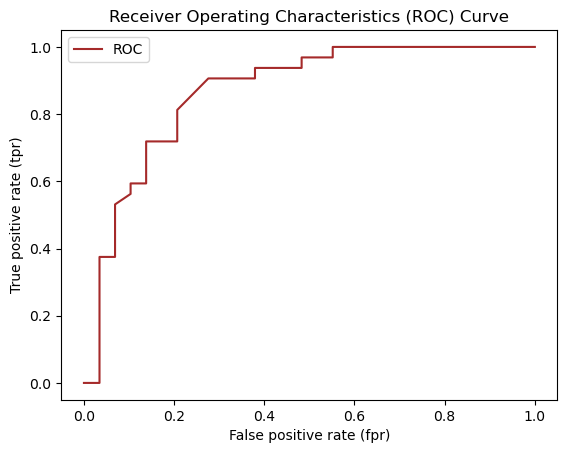

In [92]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC curve given the false +ve rate(fpr) and true +ve rate(tpr) of a model
    """
    # Plot roc curve
    plt.plot(fpr, tpr, color="brown", label="ROC")
    # Plot a line with no predictive power(baseline)
    # plt.plot([0, 1], [0, 1], color="darkblue", linestyle='--', label="Guessing")

    # Customize the plot
    plt.xlabel("False positive rate (fpr)")
    plt.ylabel("True positive rate (tpr)")
    plt.title("Receiver Operating Characteristics (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr, tpr)

***Let's look at the AUC score***

In [93]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_probs_positive)

0.8669181034482759

***Plotting a perfect ROC curve and AUC score***

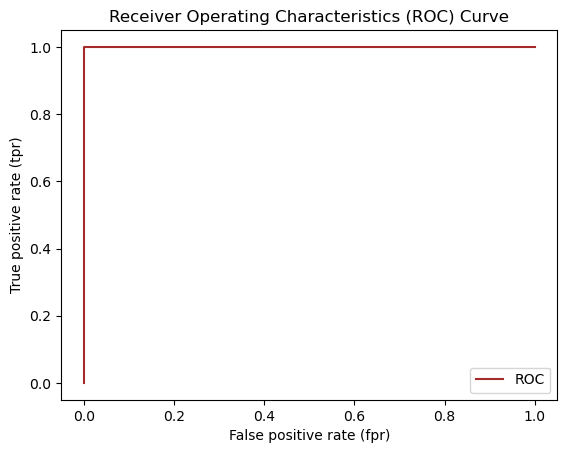

In [94]:
fpr, tpr, thresholds = roc_curve(y_test, y_test)
plot_roc_curve(fpr, tpr) # U see how handy our fc is 

***For a perfect AUC score***

In [95]:
roc_auc_score(y_test, y_test)

1.0

# 033 Evaluating A Classification Model 4 (Confusion Matrix)

***3. Confusion Matrix***

***This is a quick way to compare the labels a model predicts and the actual labels it was supposed to predict.***

***In essence, giving u an idea of where the model is getting confused***

In [96]:
from sklearn.metrics import confusion_matrix

# Now we can create a confusion matrix by making sm predictions
y_preds = clf.predict(X_test)
y_preds

array([0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [97]:
y_test

110    1
40     1
31     1
101    1
86     1
      ..
37     1
300    0
162    1
284    0
166    0
Name: target, Length: 61, dtype: int64

In [98]:
# confusion matrix
confusion_matrix(y_test, y_preds)

array([[23,  6],
       [ 6, 26]])

***Visualize confusion matrix with pd.crosstab()***

In [99]:
pd.crosstab(y_test,
           y_preds,
           rownames=["Actual Label"],
           colnames=["Predict Labels"])

Predict Labels,0,1
Actual Label,,
0,23,6
1,6,26


***From the above result from the `pd.crosstab()`, where  the `Predicted label` is `0` and the `Actual label` is `0`, we have `23` examples. And where the `Predicted label` is `1` and the `Actual label` is `1`, we have `26` examples. The total is `61`***

In [100]:
# Now checking the number of predictions is
len(y_preds) # Its also 61 bcos there are 61 examples in the test set

61

***Also we have where the `Predicted label` is `1` and the `Actual label` is `0`, we `6` examples, which is a false `+ve`. And also we have a `Predicted label` of `0` and `Actual label`of `1`, we have `6` examples, which are false `-ves`***

***This is where the word `confusion` comes into confusion matrix. These diagonals that have `6` and `6`, this is where our model is getting `Confused` predicting `0` and when label is `1` OR predicting `1` when label is `0`.***

***Also where the model got the confusion matrix right is on the diagonal also of the cross tab***

### Seaborn's heatmap() 
***Making our confusion matrix more visual with Seaborn's heatmap():***
* ***Seaborn is a visualization library that is built on top of matplotlib, and it is pretty relatively easy to use.***

***Let me show su how to insatll seaborn in our jupyter notenook, and this is how u install any lib u want to use in conda that u did not install in the terminal***

In [101]:
# Daniel used this
# import sys
# !conda install --yes --prefix {sys.prefix} seaborn
# BUT
# The below worked for me :
# %pip install seaborn

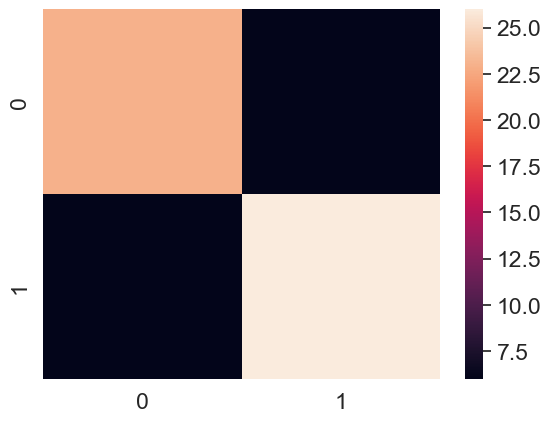

In [102]:
import seaborn as sns

# Set the front scale
sns.set(font_scale=1.5)

# Create a confusion matrix
conf_mat = confusion_matrix(y_test, y_preds)


# Plot it using Seaborn
sns.heatmap(conf_mat);

# 034 NEW Evaluating A Classification Model 5 (Confusion Matrix)¶

***This is a repeated video of the confusion matrix, but this time a difft content. This one contains how to put the numbers in the heatmap() above***

In [103]:
from sklearn.metrics import confusion_matrix 

y_preds = clf.predict(X_test)

confusion_matrix(y_test, y_preds)

array([[23,  6],
       [ 6, 26]])

**Visualizing the matrix in crosstab()**

In [104]:
pd.crosstab(y_test,
           y_preds,
           rownames=["Actual Labels"],
           colnames=["Predicted Labels"])

Predicted Labels,0,1
Actual Labels,,
0,23,6
1,6,26


***Displaying the confusion Matrix***

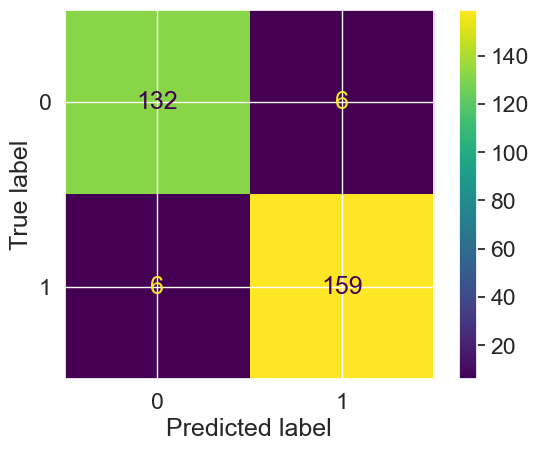

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(estimator=clf, X=X, y=y);

***Also:***

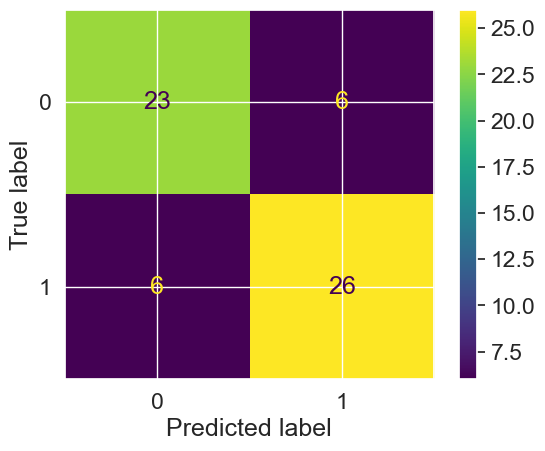

In [106]:
ConfusionMatrixDisplay.from_predictions(y_true=y_test,
                                      y_pred=y_preds);

# 035 Evaluating A Classification Model 6 (Classification Report)

***4. Classification Report***

***This is also a collection of difft evaluation metrics rather than a single one, and that's where the report comes from.***

In [107]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.79      0.79      0.79        29
           1       0.81      0.81      0.81        32

    accuracy                           0.80        61
   macro avg       0.80      0.80      0.80        61
weighted avg       0.80      0.80      0.80        61



**When to use each of these Metrics**

***Example:***

***So for e.g, let's say there were 10000 people and one of them had a disease, and u're asked to build a model to predict who had the disease.***

***This is where precision and recall bcom valuable***

In [108]:
# Creating 10000 array 
disease_true = np.zeros(10000)

# This is the only person that has it
disease_true[0] = 1 # Only one +ve case

# Model predicting every case as 0
disease_preds = np.zeros(10000)

# Creating a dataframe so we can visualize it
pd.DataFrame(classification_report(disease_true,
                                  disease_preds,
                                  output_dict=True))

C:\Users\HP\Desktop\ml-course-following\sample_project_1\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\Desktop\ml-course-following\sample_project_1\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\Desktop\ml-course-following\sample_project_1\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavio

,0.0,1.0,accuracy,macro avg,weighted avg
precision,0.99990,0.0,0.9999,0.499950,0.99980
recall,1.00000,0.0,0.9999,0.500000,0.99990
f1-score,0.99995,0.0,0.9999,0.499975,0.99985
support,9999.00000,1.0,0.9999,10000.000000,10000.00000


***The above is a prime example of where u want to use another metric other than accuracy, which is when u have a very large class imbalance.***

***So in our case, we have a massive class imbalance bcos of our original data set. Now we've built a model which predicts 0 for every case bcos it has just one sample to learn from. So it's really hard to learn that there's a pattern there for this one particular case.***

***And so what happens is, if we were to measure just accuracy on our model that is predicted `0` for everything, it comes out with an accuracy of `0.99` or`99%`.***

***And so ask urself, altho the model achieves `99.99%` accuracy, is the model still useful?***

***That's why we look at other metrics such as the `macro avg`. That's where we can see ok, our models falling down. On the precicion, it's actually getting `0` precision for `class 1`, which makes sense bcos it didn't even predict `class 1` AND on `class 0`, it is getting basically 100% bcos it has only predicted `class 0`.***

***So this is a kind of scenario of where u want to make sure that u're using  a `wide spectrum of evaluation metrics` for ur classification models and not just accuracy.***

### A Note from Dave
#### To summarize classification metrics:

* ***Accuracy*** is a good measure to start with if all classes are balanced(e.g same amount of samples which are labelled with 0 or 1).
* ***Precision*** and ***recall*** bcom more important when classes are imbalanced.
* If ***false +ve*** predictions are worse than **false -ve***, aim for higher precision
* If **false -ve*** predictions are worse than **false +ve***, aim for higher recall
* ***F1-score*** is a combination of ***precision*** and ***recall***

# 036 NEW Evaluating A Regression Model 1 (R2 Score)

### 4.2.2 Regression model evaluation metrics

***The ones we're going to cover are:***
1. **R^2 (pronounced r-squared) or co-efficient of determination**
2. **Mean abs error(MAE)**
3. **Mean squared error(MSE)**

### ***1. Using r2_score OR Co-efficient of determination***

In [109]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = housing_df.drop('target', axis=1)
y = housing_df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

***Getting the co-efficient of determination***

In [110]:
model.score(X_test, y_test)

0.806652667101436

***Let's fill an array with y_test mean***

In [111]:
from sklearn.metrics import r2_score

y_test_mean = np.full(len(y_test), y_test.mean()) # '.full(take the length to fill, values to fill)'
y_test_mean[:10]

array([2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031, 2.0550031,
       2.0550031, 2.0550031, 2.0550031, 2.0550031])

***If ur model is performing poorly, its going to get an r2_score of 0 or below 0(i.e -ve)***

In [112]:
r2_score(y_true=y_test,
        y_pred=y_test_mean)

0.0

***A perfect model will get an r2_score of 1, when this happens u need to be skeptical and also check ur data***

In [113]:
r2_score(y_true=y_test,
        y_pred=y_test)

1.0

### ***2. Mean abs error(MAE)***

***This is the avg. of the abs diff btw predictions and actual values. It gives u an idea of how wrong ur model predictions are***

In [114]:
y_preds

array([0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0])

In [115]:
y_test

20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
          ...   
15362    2.63300
16623    2.66800
18086    5.00001
2144     0.72300
3665     1.51500
Name: target, Length: 4128, dtype: float64

***Getting the mean abs error***

In [116]:
from sklearn.metrics import mean_absolute_error

y_preds = model.predict(X_test)
mae = mean_absolute_error(y_test, y_preds)
mae

0.32656738464147306

***This results or value above means that on avg. each one of our predictions is the value(`i.e 0.3265....`) y_preds `+` or `-` the y_test bcos bcos the abs gets rid of the `-ve` i.e makes all the `-ves` `+ve` values***

In [117]:
df = pd.DataFrame(data={"actual values": y_test,
                        "predicted values": y_preds})
df

,actual values,predicted values
20046,0.47700,0.493900
3024,0.45800,0.754940
15663,5.00001,4.928596
20484,2.18600,2.540240
9814,2.78000,2.331760
...,...,...
15362,2.63300,2.219830
16623,2.66800,1.947760
18086,5.00001,4.836378
2144,0.72300,0.717820


***Adding a `difference` column***

In [118]:
df["differences"] = df["predicted values"] - df["actual values"]
df.head(10)

,actual values,predicted values,differences
20046,0.47700,0.493900,0.016900
3024,0.45800,0.754940,0.296940
15663,5.00001,4.928596,-0.071414
20484,2.18600,2.540240,0.354240
9814,2.78000,2.331760,-0.448240
13311,1.58700,1.660220,0.073220
7113,1.98200,2.343100,0.361100
7668,1.57500,1.663110,0.088110
18246,3.40000,2.474890,-0.925110
5723,4.46600,4.834478,0.368478


In [119]:
df["differences"].mean()

np.float64(0.0120639253875965)

***The reason why the above `df["differences"].mean()` is difft from `mae` is bcos the `mae` turns these gets rid of the -ve. so for the `df["differences"].mean()`, its going to include the `-ve` and `ve` and we'll get a slightly difft value***

***But we can actually get the abs of the `df["differences"]` and then find the mean below:***

In [120]:
np.abs(df["differences"]).mean()

np.float64(0.32656738464147306)

# 038 NEW Evaluating A Regression Model 3 (MSE)

### ***3. Mean squared error(MSE):***

***This is the mean square of the errors btw actaul and predicted values***

In [121]:
from sklearn.metrics import mean_squared_error

y_preds = model.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
mse

0.25336408094921037

***Creating a `squared_differences` column***

In [122]:
df["squared_difference"] = np.square(df["differences"])
df.head(10)

,actual values,predicted values,differences,squared_difference
20046,0.47700,0.493900,0.016900,0.000286
3024,0.45800,0.754940,0.296940,0.088173
15663,5.00001,4.928596,-0.071414,0.005100
20484,2.18600,2.540240,0.354240,0.125486
9814,2.78000,2.331760,-0.448240,0.200919
13311,1.58700,1.660220,0.073220,0.005361
7113,1.98200,2.343100,0.361100,0.130393
7668,1.57500,1.663110,0.088110,0.007763
18246,3.40000,2.474890,-0.925110,0.855829
5723,4.46600,4.834478,0.368478,0.135776


***Calculate MSE by hand***

In [123]:
squared = np.square(df["differences"])
squared.mean()

np.float64(0.25336408094921037)

### ***Which Regression metrics should u use??***

***R^2 or r2_score is similar to accuracy. It gives u a quick indication of how well ur model might be doing. Generally, the closer ur R^2 value is to 1.0, the better the model. But it doesn't really tell exactly how wrong ur model is in terms of how far off each prediction is.***

***MAE gives a better indication of how far off each of ur model's predictiions are on avg.***

***As for MAE or MSE, bcos of th way MSE is calculated, squaring the diffs btw predicted  values and actual values, it amplifies larger diffs. Let's say we're predicting the value of houses:***

***`Pay more attention to MAE: When being $10,000 off is twice as bad as being $5000 off`***

***AND ALSO*** 

***`Pay more attention to MSE: When being $10,000 off is more than twice as bad as being $5,000 off`***

# 040 NEW Evaluating A Model With Cross Validation and Scoring Parameter

### 4.2.3 Using the `cross_validation() and the scoring parameter`

***`A point to Note:`***

***THE DIFF BTW OUR `cross_val_score() Evaluation AND regression metrics or classification metrics` IS THAT THE lATTER DEPEND ON ONE TRAIN TEST SPLIT WHILE THE FORMER ARE FOUND ON MULTIPLE TRAIN TEST SPLIT USING CROSS VALIDATION.***

***THE LATTER(`cross val`) TAKES LONGER TO FIND BCOS U HAVE TO TRAIN MULTIPLE MODELS AND EVALUATE THEM. HOWEVER, THEY ARE GENERALLY A BETTER INDICATION OF HOW UR MODEL WILL PERFORM OUTSIDE OF A JUPYTER NOTEBOOK WITH UNSEEN DATA THAN JUST ON ONE SINGLE SPLIT***

## **Cross_Validation:**

***This is spliting our dataset into multiple train and test sets and then evaluating, also training a single model on one particular train and evaluating it on that test set and then repeating that for a number of times: then getting difft scores for each difft split and then we can take the avg. of that to see how our model went across those difft splits***

In [124]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

clf = RandomForestClassifier()

## Cross validation Accuracy

**When scoring=None means that the estimator's default scorer(if available) is used (which is accuracy for classification models).**

In [125]:
cv_acc = cross_val_score(clf, X, y, cv=5, scoring=None)
cv_acc

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [126]:
print(f"The cross-validated accuracy is: {np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is: 82.48%


## A) **Using the scoring parameter for classification problem: i.e accuracy, precision and recall**

* ***i) Accuracy***

In [127]:
np.random.seed(42)

cv_accuracy = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
cv_accuracy
print(f"The cross-validated accuracy is: {np.mean(cv_acc)*100:.2f}%")

The cross-validated accuracy is: 82.48%


* ***ii) Precision***

In [128]:
np.random.seed(42)
cv_precision = cross_val_score(clf, X, y, cv=5, scoring="precision")
cv_precision

array([0.82352941, 0.93548387, 0.84848485, 0.79411765, 0.76315789])

In [129]:
print(f"The cross-validated precision is: {np.mean(cv_precision)}")

The cross-validated precision is: 0.8329547346025924


* ***iii) Recall***

In [130]:
np.random.seed(42)
cv_recall = cross_val_score(clf, X, y, cv=5, scoring="recall")
cv_recall

array([0.84848485, 0.87878788, 0.84848485, 0.81818182, 0.87878788])

In [131]:
print(f"The cross-validated recall is: {np.mean(cv_recall)}")

The cross-validated recall is: 0.8545454545454545


## B) **Using the scoring parameter for classification problem: i.e accuracy, precision and recall**

In [132]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

X = housing_df.drop("target", axis=1)
y = housing_df["target"]

model = RandomForestRegressor()

* ***i) R^2_Score***

In [133]:
np.random.seed(42)
cv_r2 = cross_val_score(model, X, y, cv=5, scoring=None) # scoring=None is bcos we want to 
# use the default score
cv_r2 

array([0.51688816, 0.70280719, 0.74200859, 0.61659773, 0.68247339])

In [134]:
np.mean(cv_r2)

np.float64(0.6521550148270838)

* ***ii) MSE***

In [135]:
np.random.seed(42)
cv_mse = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
np.mean(cv_mse)

np.float64(-0.4300986573544397)

* ***iii) MAE***

In [136]:
np.random.seed(42)
cv_mae = cross_val_score(model, X, y, cv=3, scoring="neg_mean_absolute_error")
np.mean(cv_mae)

np.float64(-0.48352491831879857)

***The main reason for cross validation is testing ur data across dift split of data to see which one does well. The no. of split u want to use is up to u depending on how large ur dataset is and how far u want to go.***

# 041 NEW Evaluating A Model With Scikit-learn Functions

### 4.3 Using difft Evaluation metrics as Scikit-Learn Fcs

***The 3rd way to evaluate Scikit-Learn machine learning models/estimators is to use the sklearn.metrics module***

**We will start with:**

***1. classification problem:***

In [137]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create X & y
X = heart_disease.drop("target", axis=1)
y = heart_disease["target"]

# Spliting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
clf = RandomForestClassifier()

# Fit model
clf.fit(X_train, y_train)

# Make predictions
y_preds = clf.predict(X_test)

### **Evaluate the model using Evaluation Fcs**

In [138]:
print(f"Classifier metrics on the test set")
print(f"Accuracy: {accuracy_score(y_test, y_preds)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_preds)}")
print(f"Recall: {recall_score(y_test, y_preds)}")
print(f"F1: {f1_score(y_test, y_preds)}")

Classifier metrics on the test set
Accuracy: 85.25%
Precision: 0.8484848484848485
Recall: 0.875
F1: 0.8615384615384616


***2) Regression problem***

In [139]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Create X & y
X = housing_df.drop('target', axis=1)
y = housing_df["target"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create model
model = RandomForestRegressor()

# Fit model
model.fit(X_train, y_train)

# Make predictions
y_preds = model.predict(X_test)

# Evaluate model using evaluation fcs
print("Regression metrics on the test set")
print(f"R2 score: {r2_score(y_test, y_preds)}")
print(f"MAE: {mean_absolute_error(y_test, y_preds)}")
print(f"MSE: {mean_squared_error(y_test, y_preds)}")

Regression metrics on the test set
R2 score: 0.806652667101436
MAE: 0.32656738464147306
MSE: 0.25336408094921037


# 042 Improving A Machine Learning Model

In [140]:
what_we_are_covering

['0. An end-to-end Scikit-Learn workflow',
 '1. Getting the data ready',
 '2. Choose the right estimator/algorithm for our problems',
 '3. Fit the model/algorithm and use it to make predictions on our data',
 '4. Evaluating a model',
 '5. Improve a model',
 '6. Save and load a trained model',
 '7. Putting it all together!']

## 5. Improving a Model

### **A) From a data perspectuve, u'll ask questions like:**

***`1. Could we collect more data?`***

***`2. Could we improve our data?`***

### **B) From a model perspective, u'll ask questions like:**

***`1. Is there a better model we could use?`***

***`2. Could we improve the current model?`***

### **Hyperparameters vs Parameters**
U***And the diff btw `parameters` and `hyper-parameters` is a ML model seeks to find patterns in that data on its own. `So a ML will find parameters on its own`, whereas `hyper-parameters are settings on a model that u can adjust.`***

### **Three ways to adjust hyperprameters:**
***1. By hand***

***2. Randomly with RandomSearchCV***

***3. Exhaustively with GridSearchCV***

#### ***This is how u find a model's hyperparameters***

In [141]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()

clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

# 043 Tuning Hyperparameters

### **5.1 Tuning hyperparameters by hand**

***From the RandomForest documentation, we will try to adjust:***

* **`max_depth`**
* **`max_features`**
* **`min_samples_leaf`**
* **`min_samples_split`**
* **`n_estimators`**

***Now since we're going to be evaluating a few models, i think it's important that we create an evaluation fc. U create a fc when ever u know u need to do smth over and over again.***

In [142]:
def evaluate_preds(y_true, y_preds):
    """
    Perfroms evaluation comparison on y_true labels vs. y_pred labels
    on a classification.
    """
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)

    metric_dict = {
        "accuracy": round(accuracy, 2),
        "precision": round(precision, 2),
        "recall": round(recall, 2),
        "f1": round(f1, 2)
    }

    print(f"Acc: {accuracy * 100: .2f}%")
    print(f"Precision: {precision: .2f}%")
    print(f"Recall: {recall: .2f}%")
    print(f"F1 score: {f1: .2f}%")

    return metric_dict

***Now we will create our train validation and test split by manually splitting our data into train validation and test sets. And let's see how we will do it below***

In [143]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [144]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)

# Shuffle the data
heart_disease_shuffled = heart_disease.sample(frac=1)
heart_disease_shuffled

# Split into X & y
X = heart_disease_shuffled.drop("target", axis=1) # This will randomly shuffle the entire dataset and
# return it as a brand-new table
y = heart_disease_shuffled["target"]

# Split the data into train, validation & test sets
train_split = round(0.7 * len(heart_disease_shuffled)) # 70% of data
valid_split = round(train_split + 0.15 * len(heart_disease_shuffled)) # 15% of data

X_train, y_train = X[:train_split], y[:train_split]
X_valid, y_valid = X[train_split:valid_split], y[train_split:valid_split] # i.e from train_split
# to valid_split
X_test, y_test = X[valid_split:], y[:valid_split] # i.e for X stop at valid_split, y from 
# valid_split onwards

# len(X_train), len(X_valid), len(X_test)

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

# Make baseline predictions
y_preds = clf.predict(X_valid)

# Evaluate the classifier on validation set
baseline_metrics = evaluate_preds(y_valid, y_preds)
baseline_metrics

Acc:  82.22%
Precision:  0.81%
Recall:  0.88%
F1 score:  0.85%


{'accuracy': 0.82, 'precision': 0.81, 'recall': 0.88, 'f1': 0.85}

***So if we were to try and improve our results, if we were to try and adjust a model's hyperparameters i.e `max_depth, max_features, min_samples_leaf, min_samples_split, n_estimators`. how would we do so?***

**Let's see how we will do so below:***

***1) So Dan changed his `n_estimator` which was at that time `10 to 100`, but mine now is already `100`, so i will change it to `200`***

In [145]:
np.random.seed(42)

# Creat a 2nd classifier with dift hyperparameters
clf_2 = RandomForestClassifier(n_estimators=200)
clf_2.fit(X_train, y_train)

# Make predictionswith difft hyperparameters
y_preds_2 = clf_2.predict(X_valid)

# Evaluate the 2nd classifier
clf_2_metrics = evaluate_preds(y_valid, y_preds_2)

Acc:  82.22%
Precision:  0.81%
Recall:  0.88%
F1 score:  0.85%


#### ***`Daves result is difft from mine as mine is still the same`***

***2. Let's see what will happen if we changed the max_depth. From documentation, `max_depth default is None`: Now if we wanrt to start changing the `hyperparameters` as it might take a long time and we might be repeating the same code with just little diff. So what we can do is use the in-built mthd in Scikit learn which is `RandomSearchCV`***

#  044 Tuning Hyperparameters 2

### ***5.2 Hyperparameter tuning with RandomizedSearchCV***

***Now most of the values u see me using is bcos of the documentation, and i have found sm values we can tune, and also years of practice. So don't feel like i just threw in sm random figures. So also if u read the documentation and practice, u would be able to come up with urs and understand what i have been doing***

***Now the below is a code chatgpt corrected for me difft from Dan's code that did not work for me***

In [146]:
from sklearn.model_selection import RandomizedSearchCV

# a) Create dictionary of hyperparameters to search
grid = {
    "n_estimators": [100, 200, 500, 1000, 1200, 1500],
    "max_depth": [None, 5, 10, 20, 30],
    "max_features": ["sqrt", "log2"],  # "auto" has been removed
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 4]
}

# Set a random seed
np.random.seed(42)

# c) Split data into X & y
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# d) Split data into training & testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# e) Instantiate the RandomForestClassifier
clf = RandomForestClassifier(random_state=42, n_jobs=1  # Use -1 if your system supports it
                            )

# f) Set up RandomizedSearchCV
rs_clf = RandomizedSearchCV(
    estimator=clf,
    param_distributions=grid,
    n_iter=10,
    cv=5,
    verbose=2,
    random_state=42
)

# g) Fit the RandomizedSearchCV version of cl
rs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.2s
[CV] END max_depth=10, max_features=sqrt, min_samples_leaf=1, min_samples_split=6, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=None, max_features=log2, min_samples_leaf=2, min_samples_split=2, n_estimato

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here

***After the model finishes running, we can call best_params(): The "best_params()" shows which combination of these models got the best results.***

In [147]:
# h) Getting the best params
rs_clf.best_params_

{'n_estimators': 100,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_features': 'sqrt',
 'max_depth': 20}

In [148]:
# i) Let's make predictions with the best hyperparameters
rs_y_preds = rs_clf.predict(X_test)

# j) Evaluate the predictions
rs_metrics = evaluate_preds(y_test, rs_y_preds) 

Acc:  83.61%
Precision:  0.80%
Recall:  0.86%
F1 score:  0.83%


***Now comparing the above score with our initial score below,is there an improvement?:***

***`Acc:  82.22%`***
***`Precision:  0.81%`***
***`Recall:  0.88%`***
***`F1 score:  0.85%`***

***There is an improvement in mine, but for Dan's, there was no improvement, which made him to say; "this is where the experimentation comes in hyperparameter tuning. U won't always find an improvement after running smth like what we did above***

***But what i want u to see is that using RandomizedSearchCV rather than running thru all these`n_estimators`, `min_samples_split`, `min_samples_leaf`, `max_features`, `max_depth` difft settings by hand, it gives us a way ro codify or functionize the tuning the hyperparameters***

# 045 Tuning Hyperparameters 3

In [149]:
grid

{'n_estimators': [100, 200, 500, 1000, 1200, 1500],
 'max_depth': [None, 5, 10, 20, 30],
 'max_features': ['sqrt', 'log2'],
 'min_samples_split': [2, 4, 6],
 'min_samples_leaf': [1, 2, 4]}

***The key diff btw RandomizedSearchCV & GridSearcgCV is: RandomizedSearchCV has a parameter called `n_iter(i.e no. of iterations)`, which is what we saw while using the RandomizedSearchCV above, which we can set to limit the number of models to try; While GridSearchCV is kind of a brute force search: This means it will go thru every single combination that is available in the `grid` we declared above***

***Using `GridSearchCV` for the above we did with `RandomSearchCV` gives `6*5*2*3*3` 540 difft combinations of parameters that would be tried. And when cross-validated will be `540*5=2700 models (remember in cross-validation it splits into 5 difft samples each time b4 the process is over).` So in total `2700 models`, which will take a lot of compute power. Training one model might take long enough time, but training `2700` of them, especailly if u're working with a large dataset, probably not going to be suitable for ur laptop: u might need a big computer or we can reduce the search space. What i mean is that we will create another grid, let's say `grid_2` using a little bit of a confined `hyperparameter space`. In essence, just reducing the no. of hyperparameters grid search has to go thru.***

***So let's see how we can reduce the search space:***

***Now we can copy and paste the grid data in grid_2 or use the `best_params_` we got as our 
grid_2, so we can do a reduced search on them.***

In [150]:
grid_2 = {'n_estimators': [100, 200, 500],
          'min_samples_split': [2],
          'min_samples_leaf': [1, 2],
          'max_features': ['sqrt', 'log2'],
          'max_depth': [20]
         }

***So what we have done here is to reduce our search space of hyperparameters. Now we've got `3*1*2*2*1 = 12`, and it will be cross-validated 5 times, which is 60 models. So this way we've reduce the search criteria and now we can perform `GridSearchCV`***

In [151]:
from sklearn.model_selection import GridSearchCV

# b) Set a random seed
np.random.seed(42)

# c) Split data into X and y
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# d) Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# e) Instantiate the RandomForestClassifier
clf = RandomForestClassifier(
    n_jobs=1  # Use -1 if your system supports it
)

# f) Set up GridSearchCV
gs_clf = GridSearchCV(
    estimator=clf,
    param_grid=grid_2,
    cv=5,
    verbose=2,
)

# g) Fit the GridSearchCV version of clf
gs_clf.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...fier(n_jobs=1)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [20], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [152]:
gs_clf.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [153]:
# h) Let's make predictions with the best hyperparameters
gs_y_preds = gs_clf.predict(X_test)

# i) Evaluate the predictions
gs_metrics = evaluate_preds(y_test, gs_y_preds) 

Acc:  85.25%
Precision:  0.79%
Recall:  0.93%
F1 score:  0.85%


***This model in my practice file did better than the one in introduction to scikit learn. I dont know why it improved but that's just it***

***But for completion, after u have tried a fair few difft hyperparameters: `u've create a baseline model with the default settings`, `u've tried to adjust them by hand`, `u tried to adjust them by RandomizedSearchCV`, and `u've tried to adjust them by GridSearchCV`, u're going to want to compare ur models:***

***Comparing our difft models metrics:***

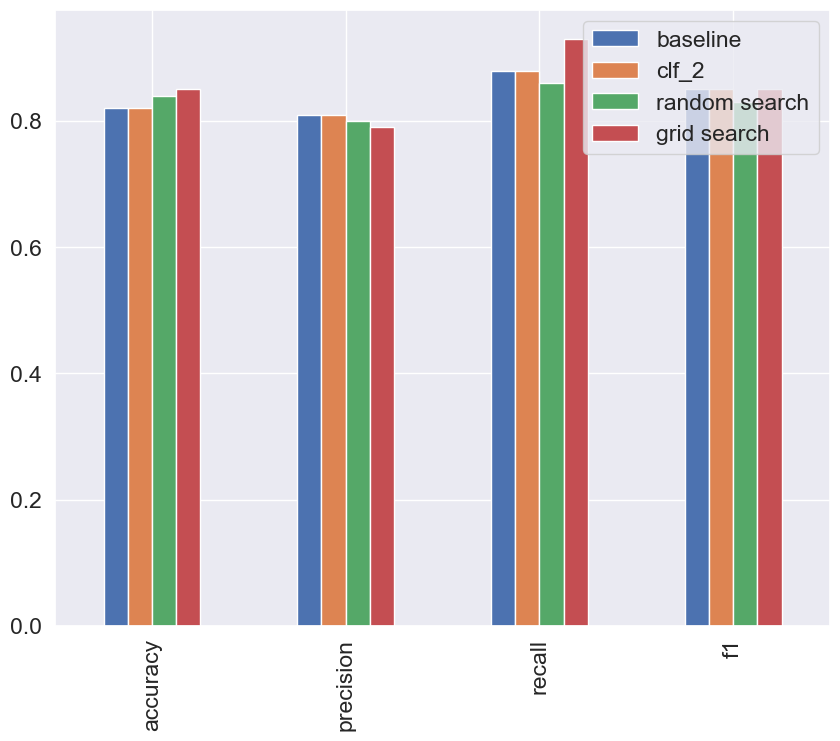

In [154]:
compare_metrics = pd.DataFrame({"baseline": baseline_metrics,
                               "clf_2": clf_2_metrics,
                               "random search": rs_metrics,
                               "grid search": gs_metrics
                              })

compare_metrics.plot.bar(figsize=(10, 8));

***Key takeaway is that in Improving a model thru hyperparameter tuning, there is no sort of written law on how u do it. The point is just keep trying to see if u can figure out smth, see if u can keep urself familarize with difft hyperparameters that difft models have, and just remind urself that the 1st model that u make is more than likely not the best model that u'll have. It's a baseline model and it can be improved upon***

# 048 Saving And Loading A Model

## 6. Saving and Loading trained ML models

***There are 2 ways of saving and loading ML models:***
1. ***With python's `pickle` module***
2. ***With the `joblib` module***

***1. Pickle***

In [155]:
import pickle

# Save an existing model to file
pickle.dump(gs_clf, open("gs_random_random_forest_model_1.pkl", 'wb')) # wb = write binary

In [156]:
# Load a saved model
loaded_pickle_model = pickle.load(open("gs_random_random_forest_model_1.pkl", "rb")) 
# rb = read binary

In [157]:
# Make sm predictions

np.random.seed(42)

# c) Split data into X and y
X = heart_disease_shuffled.drop("target", axis=1)
y = heart_disease_shuffled["target"]

# d) Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
)

In [158]:
gs_clf.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [159]:
pickle_y_preds = loaded_pickle_model.predict(X_test)
evaluate_preds(y_test, pickle_y_preds)

Acc:  85.25%
Precision:  0.79%
Recall:  0.93%
F1 score:  0.85%


{'accuracy': 0.85, 'precision': 0.79, 'recall': 0.93, 'f1': 0.85}

# 049 Saving And Loading A Model 2

***2. Joblib***

In [160]:
from joblib import dump, load

# Save model to file
dump(gs_clf, filename="gs_random_forest_model_1.joblib")

['gs_random_forest_model_1.joblib']

In [161]:
# Import a saved joblib model
loaded_joblib_model = load(filename="gs_random_forest_model_1.joblib")

In [162]:
# Make and evaluate joblib predictions
joblib_y_preds = loaded_joblib_model.predict(X_test)
evaluate_preds(y_test, joblib_y_preds)

Acc:  85.25%
Precision:  0.79%
Recall:  0.93%
F1 score:  0.85%


{'accuracy': 0.85, 'precision': 0.79, 'recall': 0.93, 'f1': 0.85}

***Which should u use:***

***`According to Scikit learn documentation, in the specific case of scikit, it may be better to use joblib's replacement of pickle(dump & load), which is more efficient on objects that carry large numpy arrays internally as is often the case for fitted scikit-learn estimators, but can only pickle to the disk and not to a string`***

# 050 Putting It All Together

## 7. Putting it all together

In [163]:
data = pd.read_csv("data/car-sales-extended-missing-data.csv")
data

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [164]:
data.dtypes

Make                 str
Colour               str
Odometer (KM)    float64
Doors            float64
Price            float64
dtype: object

In [165]:
data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

### Things to remember

***`All data should be numerical`***

***`There should be no missing values`***

***`Manupulate the test set the same as the training set`***

***`Never test on data u've trained on`***

***`Tune hyperparameter on validation set OR use cross-validation`***

***`One best performance metric doesn't mean the best model`***

## Steps we want to do
#### ***1. Fill missing data***
#### ***2. Convert data to numbers***
#### ***3. Build a model on the data***

In [166]:
# Getting data ready 
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline # This isb what will do the putting together
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Modelling
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

# Setup random seed
import numpy as np
np.random.seed(42)

# Import data and drop rows with missing labels
data = pd.read_csv("data/car-sales-extended-missing-data.csv")
data = data.dropna(subset=["Price"])

# Define difft features and transformer pipeline
categorical_features = ["Make", "Colour"]
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")) # This turns all our data that is 
    # not numbers to numbers
])

door_feature = ["Doors"]
door_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value=4))
])

numeric_features = ["Odometer (KM)"]
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Setup of the preprocessing steps(fill missing values, then covert to numbers)
preprocessor = ColumnTransformer(
    transformers = [
        ("cat", categorical_transformer, categorical_features),
        ("door", door_transformer, door_feature),
        ("num", numeric_transformer, numeric_features)
        
    ]
)

# Creating a preprocessing and modelling pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor())
])

# Split data
X = data.drop("Price", axis=1)
y = data["Price"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Fit and score the model
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.22188417408787875

# 051 Putting It All Together 2

***Now it is also possible to use `GridSearchCV` OR `RandomizedSearchCV` with our pipeline. There's a slight little diff here and it'll make sense once we run the code***,

***So let's see how we can use GtidSearchCV to find better hyperparameters, better settings on our RandomForestRegressor and hopefully improve the score `0.22188....`***

In [ ]:
# Use GridSearchCV with our Regressor pipeline
# We already imported GridSearcCV

pipe_grid = {
    # 1) This is accessing the parameters
    "preprocessor__num__imputer__strategy": ["mean", "median"], 
    # 2) Accessing the model. I used 200 bcos as at now the default is 100 for n_estimators
    "model__n_estimators": [200, 1000],  # we only neeed one double underscore bcos we are 
    # going up just one level i.e from here ("model", RandomForestRegressor())
    "model__max_depth": [None, 5],
    "model__max_features": ["sqrt"],
    "model__min_samples_split": [2, 4]
}

# Crreating a grid search model
gs_model = GridSearchCV(model, pipe_grid, cv=5, verbose=2)
gs_model.fit(X_train, y_train)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=200, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=200, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=200, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=200, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_samples_split=2, model__n_estimators=200, preprocessor__num__imputer__strategy=mean; total time=   0.2s
[CV] END model__max_depth=None, model__max_features=sqrt, model__min_sampl

***This is what this key refers to `preprocessor__num__imputer__strategy`: From this pipeline `("preprocessor", preprocessor)` we get our `preprocessor`. The `double underscore (__)` leads to `num`. So it will come to our `preprocessor` on this line `preprocessor = ColumnTransformer` to look for the `num key` which has this `numeric_transformer` as a value which is a pipeline also. From there, the next `double underscore (__)` searches for `imputer` in this pipeline `("imputer", SimpleImputer(strategy="mean"))`. This then goes thru the next `double underscore (__)` to look for `strategy on that same line ("imputer", SimpleImputer(strategy="mean"))`***

***This process is what is done for every part of the `pipe_grid`***

***Now know that  the speed of the models is dependent on how fast ur computer is. Now u may need to wait for a while. So this is why it's always important to be careful how many parameters u pass to GridSearchCV bcos it is gong to exhaustively search for every single combination.***

### **Checking if the model increased**

In [ ]:
gs_model.score(X_test, y_test)

***It fairly improved the model from `0.22188...` to `0.29408....`. we may continue to improve it, but let's leave it as this.***